# 07 - SMC Entry Trigger (LTF)
Enter trade when M5 CHoCH/BOS confirms inside M15 OB+FVG zone, aligned with H4 bias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import os
from dotenv import load_dotenv
load_dotenv()
import MetaTrader5 as mt5

mt5.initialize()
login = int(os.getenv('MT5_LOGIN', '0'))
password = os.getenv('MT5_PASSWORD')
server = os.getenv('MT5_SERVER', '').strip()
mt5.login(login, password=password, server=server)
print('Ready')

Ready


## 1. Fetch Data — H4 (bias) + M15 (zones) + M5 (entry)

In [2]:
h4 = pd.DataFrame(mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_H4, 0, 500))
m15 = pd.DataFrame(mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_M15, 0, 2000))
m5 = pd.DataFrame(mt5.copy_rates_from_pos('EURUSD', mt5.TIMEFRAME_M5, 0, 2000))
mt5.shutdown()

for df in [h4, m15, m5]:
    df['time'] = pd.to_datetime(df['time'], unit='s')
    df.set_index('time', inplace=True)

print(f'H4:  {len(h4)} bars  ({h4.index[0]} → {h4.index[-1]})')
print(f'M15: {len(m15)} bars ({m15.index[0]} → {m15.index[-1]})')
print(f'M5:  {len(m5)} bars  ({m5.index[0]} → {m5.index[-1]})')

H4:  500 bars  (2026-02-03 16:00:00 → 2026-05-29 20:00:00)
M15: 2000 bars (2026-05-01 04:00:00 → 2026-05-29 23:45:00)
M5:  2000 bars  (2026-05-21 01:15:00 → 2026-05-29 23:55:00)


## 2. H4 Bias Engine

In [3]:
def find_swings(df, left=2, right=2):
    highs, lows = [], []
    for i in range(left, len(df) - right):
        if df['high'].iloc[i] == df['high'].iloc[i-left:i+right+1].max():
            highs.append({'index': df.index[i], 'price': df['high'].iloc[i]})
        if df['low'].iloc[i] == df['low'].iloc[i-left:i+right+1].min():
            lows.append({'index': df.index[i], 'price': df['low'].iloc[i]})
    return highs, lows

h4_highs, h4_lows = find_swings(h4)
current_close = h4['close'].iloc[-1]
prev_high = h4_highs[-2]['price'] if len(h4_highs) >= 2 else None
prev_low = h4_lows[-2]['price'] if len(h4_lows) >= 2 else None

if prev_high and current_close > prev_high:
    h4_bias = 'bullish'
elif prev_low and current_close < prev_low:
    h4_bias = 'bearish'
else:
    h4_bias = 'neutral'

print(f'H4 BIAS: {h4_bias.upper()}')
print(f'Range: {prev_low:.5f} - {prev_high:.5f}')
print(f'Close: {current_close:.5f}')

H4 BIAS: NEUTRAL
Range: 1.15856 - 1.16608
Close: 1.16589


## 3. M15 Zone Detection — OB + FVG + Confluence

In [4]:
def find_fvg(df, min_gap=0.00005):
    fvgs = []
    for i in range(2, len(df)):
        c1, c2, c3 = df.iloc[i-2], df.iloc[i-1], df.iloc[i]
        if c3['low'] > c1['high']:
            fvgs.append({'time': df.index[i], 'type': 'bullish_fvg', 'top': c3['low'], 'bottom': c1['high'], 'mid': (c3['low']+c1['high'])/2})
        if c3['high'] < c1['low']:
            fvgs.append({'time': df.index[i], 'type': 'bearish_fvg', 'top': c1['low'], 'bottom': c3['high'], 'mid': (c1['low']+c3['high'])/2})
    return pd.DataFrame(fvgs) if fvgs else pd.DataFrame()

def find_order_blocks(df, impulse_min=0.0010):
    obs = []
    for i in range(1, len(df)):
        prev, curr = df.iloc[i-1], df.iloc[i]
        if prev['close'] < prev['open'] and curr['close'] - curr['open'] >= impulse_min:
            obs.append({'time': df.index[i], 'type': 'bullish_ob', 'top': max(prev['open'], prev['close']), 'bottom': min(prev['open'], prev['close']), 'mid': (max(prev['open'], prev['close'])+min(prev['open'], prev['close']))/2})
        if prev['close'] > prev['open'] and curr['open'] - curr['close'] >= impulse_min:
            obs.append({'time': df.index[i], 'type': 'bearish_ob', 'top': max(prev['open'], prev['close']), 'bottom': min(prev['open'], prev['close']), 'mid': (max(prev['open'], prev['close'])+min(prev['open'], prev['close']))/2})
    return pd.DataFrame(obs) if obs else pd.DataFrame()

fvgs = find_fvg(m15)
obs = find_order_blocks(m15)
print(f'M15 FVG: {len(fvgs)} | OB: {len(obs)}')

M15 FVG: 428 | OB: 14


In [5]:
# Filter by H4 bias + find confluence zones
def filter_zones(obs, fvgs, bias):
    if bias == 'bullish':
        return obs[obs['type']=='bullish_ob'].copy() if len(obs)>0 else pd.DataFrame(), fvgs[fvgs['type']=='bullish_fvg'].copy() if len(fvgs)>0 else pd.DataFrame()
    elif bias == 'bearish':
        return obs[obs['type']=='bearish_ob'].copy() if len(obs)>0 else pd.DataFrame(), fvgs[fvgs['type']=='bearish_fvg'].copy() if len(fvgs)>0 else pd.DataFrame()
    return obs.copy() if len(obs)>0 else pd.DataFrame(), fvgs.copy() if len(fvgs)>0 else pd.DataFrame()

def find_confluence(obs, fvgs, max_dist=0.0005):
    if len(obs)==0 or len(fvgs)==0:
        return pd.DataFrame()
    overlaps = []
    for _, ob in obs.iterrows():
        for _, fvg in fvgs.iterrows():
            if ob['type'].split('_')[0] != fvg['type'].split('_')[0]:
                continue
            if abs(ob['mid'] - fvg['mid']) <= max_dist:
                overlaps.append({
                    'time': max(ob['time'], fvg['time']),
                    'direction': ob['type'].split('_')[0],
                    'zone_top': max(ob['top'], fvg['top']),
                    'zone_bottom': min(ob['bottom'], fvg['bottom']),
                    'zone_mid': (max(ob['top'], fvg['top'])+min(ob['bottom'], fvg['bottom']))/2
                })
    return pd.DataFrame(overlaps).sort_values('time') if overlaps else pd.DataFrame()

valid_obs, valid_fvg = filter_zones(obs, fvgs, h4_bias)
confluence = find_confluence(valid_obs, valid_fvg)
print(f'Valid OB: {len(valid_obs)} | Valid FVG: {len(valid_fvg)} | Confluence: {len(confluence)}')

Valid OB: 14 | Valid FVG: 428 | Confluence: 180


In [6]:
# Show recent confluence zones (last 5)
if len(confluence) > 0:
    recent = confluence.tail(5).copy()
    print('Recent confluence zones:')
    for _, z in recent.iterrows():
        print(f"  {z['time']} | {z['direction']} | ${z['zone_mid']:.5f} ({z['zone_bottom']:.5f}-{z['zone_top']:.5f})")
else:
    print('No confluence zones found.')

Recent confluence zones:
  2026-05-28 17:15:00 | bullish | $1.16391 (1.16368-1.16414)
  2026-05-29 08:15:00 | bullish | $1.16387 (1.16368-1.16407)
  2026-05-29 13:00:00 | bullish | $1.16330 (1.16287-1.16373)
  2026-05-29 13:00:00 | bullish | $1.16370 (1.16367-1.16373)
  2026-05-29 13:00:00 | bullish | $1.16337 (1.16301-1.16373)


## 4. M5 Entry Trigger — CHoCH inside Zone
Check if M5 price is inside a confluence zone and shows CHoCH/BOS

In [7]:
def detect_choch_m5(df, swings_dir, max_candles=20):
    """Detect CHoCH on M5. swings_dir = 'bullish' for HL→break high, 'bearish' for LH→break low."""
    highs, lows = find_swings(df)
    if swings_dir == 'bullish' and len(lows) >= 3:
        curr, prev, pp = lows[-1], lows[-2], lows[-3]
        if pp['price'] > prev['price'] and curr['price'] > prev['price']:
            recent_highs = [h for h in highs if h['index'] < curr['index']]
            if recent_highs:
                break_high = recent_highs[-1]
                after = df[df.index > curr['index']].head(max_candles)
                if len(after) > 0 and after['high'].max() > break_high['price']:
                    return {'detected': True, 'direction': 'bullish', 'price': after['high'].max(), 'time': after['high'].idxmax()}
    elif swings_dir == 'bearish' and len(highs) >= 3:
        curr, prev, pp = highs[-1], highs[-2], highs[-3]
        if pp['price'] < prev['price'] and curr['price'] < prev['price']:
            recent_lows = [l for l in lows if l['index'] < curr['index']]
            if recent_lows:
                break_low = recent_lows[-1]
                after = df[df.index > curr['index']].head(max_candles)
                if len(after) > 0 and after['low'].min() < break_low['price']:
                    return {'detected': True, 'direction': 'bearish', 'price': after['low'].min(), 'time': after['low'].idxmin()}
    return {'detected': False}

def is_price_in_zone(price, zone):
    return zone['zone_bottom'] <= price <= zone['zone_top']

current_m5_price = m5['close'].iloc[-1]
print(f'Current M5 price: {current_m5_price:.5f}')
print(f'H4 Bias: {h4_bias.upper()}')

signals = []
if len(confluence) > 0:
    # Find nearest confluence zone to current price
    for _, zone in confluence.iterrows():
        if not is_price_in_zone(current_m5_price, zone):
            continue
        # M5 CHoCH in the zone direction
        choch = detect_choch_m5(m5, zone['direction'])
        if choch['detected']:
            # Confirm with H4 bias
            if h4_bias != 'neutral' and zone['direction'] != h4_bias:
                continue
            # Calculate SL/TP
            m5_highs, m5_lows = find_swings(m5)
            if zone['direction'] == 'bullish':
                sl = m5_lows[-1]['price'] - 0.0001 if len(m5_lows) > 0 else current_m5_price - 0.0010
                tp = m5_highs[-1]['price'] + 0.0005 if len(m5_highs) > 0 else current_m5_price + 0.0020
            else:
                sl = m5_highs[-1]['price'] + 0.0001 if len(m5_highs) > 0 else current_m5_price + 0.0010
                tp = m5_lows[-1]['price'] - 0.0005 if len(m5_lows) > 0 else current_m5_price - 0.0020
            signals.append({
                'direction': zone['direction'],
                'entry': current_m5_price,
                'sl': sl,
                'tp': tp,
                'risk_pips': abs(current_m5_price - sl) * 10000,
                'reward_pips': abs(tp - current_m5_price) * 10000,
                'rr': abs(tp - current_m5_price) / abs(current_m5_price - sl) if abs(current_m5_price - sl) > 0 else 0,
                'zone_mid': zone['zone_mid'],
                'choch_time': choch['time']
            })

if len(signals) > 0:
    print(f'\nSIGNALS FOUND: {len(signals)}')
    for s in signals:
        print(f"  {s['direction'].upper()} | Entry: {s['entry']:.5f} | SL: {s['sl']:.5f} | TP: {s['tp']:.5f} | R:R {s['rr']:.2f}")
else:
    print('\nNO SIGNAL — price not in zone, or no M5 CHoCH/BOS confirmation')

Current M5 price: 1.16589
H4 Bias: NEUTRAL

NO SIGNAL — price not in zone, or no M5 CHoCH/BOS confirmation


## 5. Summary + Visualization

In [8]:
# Summary
print('=' * 55)
print('LTF ENTRY TRIGGER - SUMMARY')
print('=' * 55)
print(f'H4 Bias:     {h4_bias.upper()}')
print(f'M15 Zones:   OB={len(valid_obs)}, FVG={len(valid_fvg)}, Confluence={len(confluence)}')
print(f'M5 Price:    {current_m5_price:.5f}')
print(f'Trade:       {"YES" if len(signals) > 0 else "NO — wait"}')
if len(signals) > 0:
    s = signals[0]
    print(f'Direction:   {s["direction"].upper()}')
    print(f'Entry:       {s["entry"]:.5f}')
    print(f'SL:          {s["sl"]:.5f}')
    print(f'TP:          {s["tp"]:.5f}')
    print(f'R:R:         {s["rr"]:.2f}')
else:
    print('Advice: Wait for price to enter confluence zone + M5 confirmation')
print('=' * 55)

LTF ENTRY TRIGGER - SUMMARY
H4 Bias:     NEUTRAL
M15 Zones:   OB=14, FVG=428, Confluence=180
M5 Price:    1.16589
Trade:       NO — wait
Advice: Wait for price to enter confluence zone + M5 confirmation


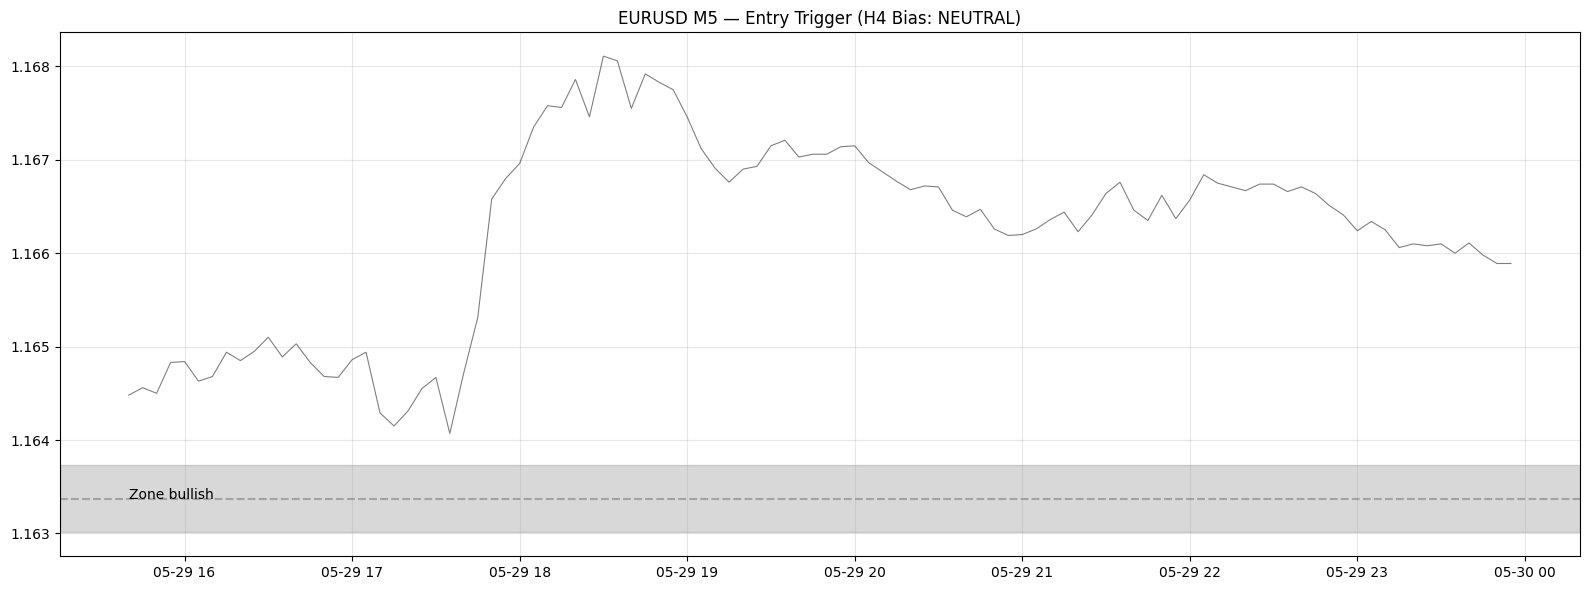

In [9]:
# M5 chart with zone + entry/SL/TP
fig, ax = plt.subplots(figsize=(16, 6))
plot_data = m5.tail(100)
ax.plot(plot_data.index, plot_data['close'], color='black', linewidth=0.8, alpha=0.5)

zone_color = 'green' if h4_bias == 'bullish' else 'red' if h4_bias == 'bearish' else 'gray'

# Draw confluence zone if any
if len(confluence) > 0:
    last_zone = confluence.iloc[-1]
    ax.axhspan(last_zone['zone_bottom'], last_zone['zone_top'], alpha=0.3, color=zone_color)
    ax.axhline(y=last_zone['zone_mid'], color=zone_color, linestyle='--', alpha=0.6)
    ax.text(plot_data.index[0], last_zone['zone_mid'], f'Zone {last_zone["direction"]}', fontsize=10)

# Draw entry/SL/TP if signal
if len(signals) > 0:
    s = signals[0]
    color = 'green' if s['direction'] == 'bullish' else 'red'
    ax.axhline(y=s['entry'], color=color, linestyle='-', linewidth=2, alpha=0.8)
    ax.axhline(y=s['sl'], color='red', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axhline(y=s['tp'], color='green', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(plot_data.index[-5], s['entry'], f'Entry {s["entry"]:.5f}', fontsize=9)
    ax.text(plot_data.index[-5], s['sl'], f'SL {s["sl"]:.5f}', fontsize=9, color='red')
    ax.text(plot_data.index[-5], s['tp'], f'TP {s["tp"]:.5f}', fontsize=9, color='green')

ax.set_title(f'EURUSD M5 — Entry Trigger (H4 Bias: {h4_bias.upper()})')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()